# Universidad Autónoma de Aguascalientes

# Departamento: Ciencias de la Computación

# Carrera: Ingeniería en Computación Inteligente

## Curso: Aprendizaje Automático

## Maestro: Dr. Francisco Javier Luna Rosas

## Alumno: Carlos Leonardo Cruz Ortiz

### Semestre: Enero-Junio del 2026

# EXAMEN PARCIAL 1: Análisis e Implementación de Algoritmos de Aprendizaje por Refuerzo

## Paso 1: Importar librerías necesarias y declaración de cosas importantes

In [108]:
from collections import deque
from enum import StrEnum
import random
import time
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import Env
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

dqn_model_exists = lambda:os.path.exists("../models/dqn_model/dqn_checkpoint.pth")

# Reproducibilidad
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

In [109]:
class Icons(StrEnum):
  CHECK = "✓"
  CROSS = "✗"
  INFO = "ℹ"

def print_success(message: str):
  print(f"{Icons.CHECK} {message}")


def print_failure(message: str):
  print(f"{Icons.CROSS} {message}")


def print_info(message: str):
  print(f"{Icons.INFO} {message}")


print_success("Librerías importadas exitosamente")
print_info(f"Gymnasium versión: {gym.__version__}")
print_info(f"PyTorch versión: {torch.__version__}")
print_info(f"NumPy versión: {np.__version__}")

✓ Librerías importadas exitosamente
ℹ Gymnasium versión: 1.2.3
ℹ PyTorch versión: 2.7.1+cu118
ℹ NumPy versión: 2.4.2


## Paso 2: Descripción del entorno Taxi-v3

In [110]:
# Crear el entorno Taxi-v3
env = gym.make('Taxi-v3', render_mode='ansi')

print_info("Información del entorno:")
print(f"Espacio de estados: {env.observation_space}")
print(f"Número de estados: {env.observation_space.n}")
print(f"Espacio de acciones: {env.action_space}")
print(f"Número de acciones: {env.action_space.n}")

# Reiniciar y visualizar estado inicial
state, info = env.reset()
print(f"\n  Estado inicial (codificado): {state}")
print("\nVisualización del estado inicial:")
print(env.render())

ℹ Información del entorno:
Espacio de estados: Discrete(500)
Número de estados: 500
Espacio de acciones: Discrete(6)
Número de acciones: 6

  Estado inicial (codificado): 382

Visualización del estado inicial:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




## Paso 3: Exploración del entorno con agente aleatorio

In [111]:
def run_random_agent(env, num_episodes=5, max_steps=100):
  """Ejecuta episodios con acciones aleatorias para explorar el entorno."""

  episode_rewards = []
  episode_steps = []

  for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    steps = 0

    print(f"\n{'='*50}")
    print(f"Episodio {episode + 1}")
    print(f"{'='*50}")
    print(env.render())

    for _ in range(max_steps):
      action = env.action_space.sample()
      next_state, reward, terminated, truncated, info = env.step(action)

      total_reward += reward
      steps += 1
      state = next_state

      if terminated or truncated:
        break

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    print(f"\nResultado: Recompensa total = {total_reward}, Pasos = {steps}")
    if total_reward > 0:
      print_success("¡Episodio exitoso!")
    else:
      print_failure("Episodio sin éxito")

  print(f"\n{'='*50}")
  print("Estadísticas del agente aleatorio:")
  print(f"  Recompensa promedio: {np.mean(episode_rewards):.2f}")
  print(f"  Pasos promedio: {np.mean(episode_steps):.2f}")
  print(f"  Tasa de éxito: {sum(1 for r in episode_rewards if r > 0) / num_episodes * 100:.1f}%")

  return episode_rewards, episode_steps


# Ejecutar agente aleatorio
random_rewards, random_steps = run_random_agent(env, num_episodes=3, max_steps=100)


Episodio 1
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



Resultado: Recompensa total = -406, Pasos = 100
✗ Episodio sin éxito

Episodio 2
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



Resultado: Recompensa total = -397, Pasos = 100
✗ Episodio sin éxito

Episodio 3
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



Resultado: Recompensa total = -388, Pasos = 100
✗ Episodio sin éxito

Estadísticas del agente aleatorio:
  Recompensa promedio: -397.00
  Pasos promedio: 100.00
  Tasa de éxito: 0.0%


## Paso 4: Implementación de Q-Learning

In [112]:
class QLearningAgent:
  """Agente de Q-Learning para entornos discretos."""

  def __init__(self, n_states, n_actions, learning_rate=0.1, discount_factor=0.99,
               epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
    self.n_states = n_states
    self.n_actions = n_actions
    self.lr = learning_rate
    self.gamma = discount_factor
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay

    # Tabla Q inicializada en ceros
    self.q_table = np.zeros((n_states, n_actions))

  def select_action(self, state, training=True):
    """Selecciona acción usando política epsilon-greedy."""
    if training and random.random() < self.epsilon:
      return random.randint(0, self.n_actions - 1)  # Exploración
    else:
      return np.argmax(self.q_table[state])  # Explotación (mejor acción conocida)

  def update(self, state, action, reward, next_state, done):
    """Actualiza la tabla Q usando la ecuación de Q-Learning."""
    current_q = self.q_table[state, action]

    # Off-policy: usa el máximo valor Q del siguiente estado
    max_next_q = np.max(self.q_table[next_state]) if not done else 0

    # Q(s,a) ← Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]
    new_q = current_q + self.lr * (reward + self.gamma * max_next_q - current_q)
    self.q_table[state, action] = new_q

  def decay_epsilon(self):
    """Reduce epsilon para explorar menos con el tiempo."""
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [113]:
def train_qlearning(env: Env, num_episodes=15000):
  """Entrena un agente Q-Learning y registra métricas."""

  agent = QLearningAgent(
    n_states=env.observation_space.n,
    n_actions=env.action_space.n,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995
  )

  episode_rewards = []
  episode_steps = []
  success_rate = []  # Ventana móvil de 100 episodios
  recent_successes = deque(maxlen=100)

  print_info("Entrenando Q-Learning...")
  start_time = time.time()

  for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    steps = 0
    done = False

    while not done:
      action = agent.select_action(state, training=True)
      next_state, reward, terminated, truncated, info = env.step(action)
      done = terminated or truncated

      agent.update(state, action, reward, next_state, done)

      total_reward += reward
      steps += 1
      state = next_state

    # Registrar métricas
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    recent_successes.append(1 if total_reward > 0 else 0)
    success_rate.append(np.mean(recent_successes))

    agent.decay_epsilon()

    # Progreso cada 1000 episodios
    if (episode + 1) % 1000 == 0:
      avg_reward = np.mean(episode_rewards[-100:])
      avg_steps = np.mean(episode_steps[-100:])
      current_success = success_rate[-1] * 100
      print_info(f"Episodio {episode + 1}/{num_episodes} | "
            f"Recompensa: {avg_reward:.2f} | "
            f"Pasos: {avg_steps:.1f} | "
            f"Éxito: {current_success:.1f}% | "
            f"ε: {agent.epsilon:.3f}")

  training_time = time.time() - start_time
  print_success(f"Entrenamiento completado en {training_time:.2f} segundos")

  return agent, {
    'rewards': episode_rewards,
    'steps': episode_steps,
    'success_rate': success_rate,
    'training_time': training_time
  }

qlearning_agent, qlearning_metrics = train_qlearning(env, num_episodes=10000)

ℹ Entrenando Q-Learning...
ℹ Episodio 1000/10000 | Recompensa: -166.82 | Pasos: 66.8 | Éxito: 2.0% | ε: 0.606
ℹ Episodio 2000/10000 | Recompensa: -24.48 | Pasos: 22.1 | Éxito: 11.0% | ε: 0.368
ℹ Episodio 3000/10000 | Recompensa: -7.12 | Pasos: 17.6 | Éxito: 34.0% | ε: 0.223
ℹ Episodio 4000/10000 | Recompensa: -0.51 | Pasos: 15.7 | Éxito: 55.0% | ε: 0.135
ℹ Episodio 5000/10000 | Recompensa: 3.55 | Pasos: 14.1 | Éxito: 69.0% | ε: 0.082
ℹ Episodio 6000/10000 | Recompensa: 4.08 | Pasos: 14.2 | Éxito: 77.0% | ε: 0.050
ℹ Episodio 7000/10000 | Recompensa: 6.03 | Pasos: 14.2 | Éxito: 91.0% | ε: 0.030
ℹ Episodio 8000/10000 | Recompensa: 7.21 | Pasos: 13.2 | Éxito: 95.0% | ε: 0.018
ℹ Episodio 9000/10000 | Recompensa: 6.98 | Pasos: 12.9 | Éxito: 89.0% | ε: 0.011
ℹ Episodio 10000/10000 | Recompensa: 7.87 | Pasos: 12.9 | Éxito: 99.0% | ε: 0.010
✓ Entrenamiento completado en 6.75 segundos


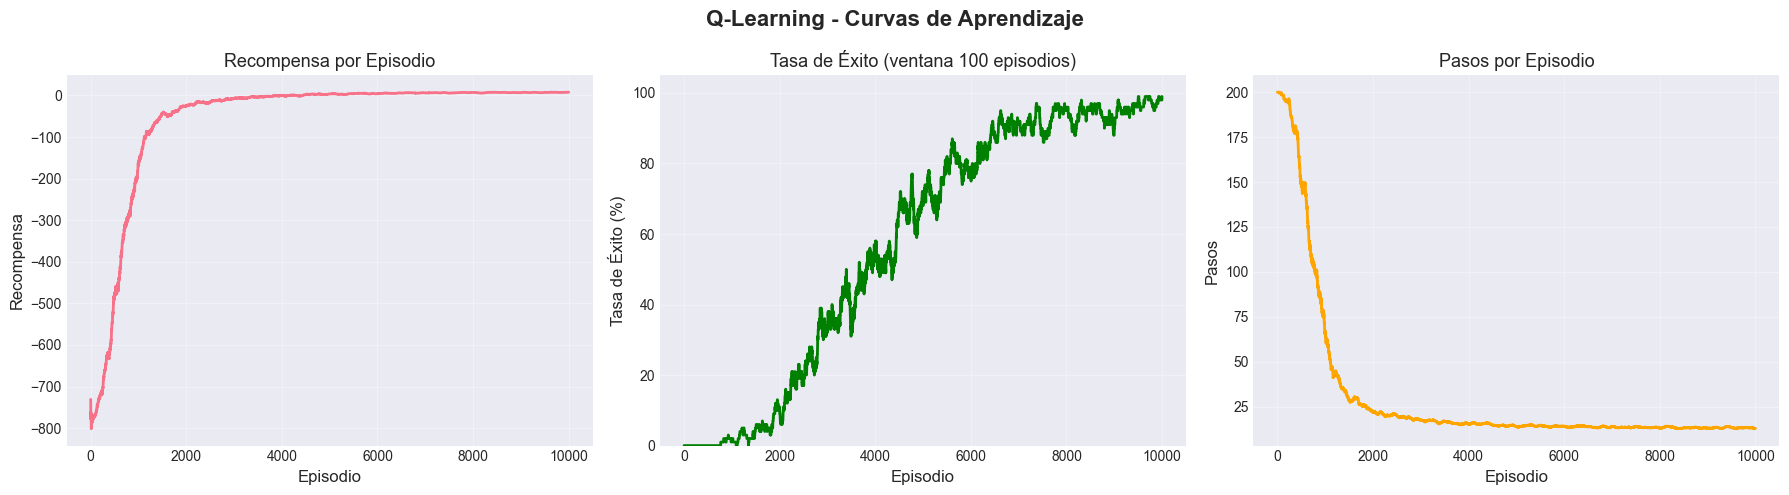

In [114]:
# Visualizar curvas de aprendizaje de Q-Learning
def plot_training_curves(metrics, title, window=100):
  """Grafica las curvas de aprendizaje con suavizado."""

  fig, axes = plt.subplots(1, 3, figsize=(18, 5))
  fig.suptitle(title, fontsize=16, fontweight='bold')

  def smooth(data, window):
    return pd.Series(data).rolling(window=window, min_periods=1).mean()

  # Gráfica 1: Recompensas
  axes[0].plot(smooth(metrics['rewards'], window), linewidth=2)
  axes[0].set_xlabel('Episodio', fontsize=12)
  axes[0].set_ylabel('Recompensa', fontsize=12)
  axes[0].set_title('Recompensa por Episodio', fontsize=13)
  axes[0].grid(True, alpha=0.3)

  # Gráfica 2: Tasa de éxito
  axes[1].plot(np.array(metrics['success_rate']) * 100, linewidth=2, color='green')
  axes[1].set_xlabel('Episodio', fontsize=12)
  axes[1].set_ylabel('Tasa de Éxito (%)', fontsize=12)
  axes[1].set_title('Tasa de Éxito (ventana 100 episodios)', fontsize=13)
  axes[1].grid(True, alpha=0.3)
  axes[1].set_ylim([0, 105])

  # Gráfica 3: Pasos por episodio
  axes[2].plot(smooth(metrics['steps'], window), linewidth=2, color='orange')
  axes[2].set_xlabel('Episodio', fontsize=12)
  axes[2].set_ylabel('Pasos', fontsize=12)
  axes[2].set_title('Pasos por Episodio', fontsize=13)
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()


plot_training_curves(qlearning_metrics, 'Q-Learning - Curvas de Aprendizaje')

## Paso 5: Implementación de DQN (Deep Q-Network)

In [115]:
class DQNNetwork(nn.Module):
  """Red neuronal para aproximar la función Q."""

  def __init__(self, n_states, n_actions, hidden_size=128):
    super(DQNNetwork, self).__init__()
    # Red feed-forward con 2 capas ocultas
    self.fc1 = nn.Linear(n_states, hidden_size)
    self.fc2 = nn.Linear(hidden_size, hidden_size)
    self.fc3 = nn.Linear(hidden_size, n_actions)

  def forward(self, x):
    """Propagación hacia adelante."""
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return self.fc3(x)  # Valores Q para cada acción


class ReplayBuffer:
  """Buffer de memoria para Experience Replay."""

  def __init__(self, capacity=10000):
    self.buffer = deque(maxlen=capacity)

  def push(self, state, action, reward, next_state, done):
    """Almacena una transición."""
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self, batch_size):
    """Muestrea un batch aleatorio."""
    batch = random.sample(self.buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    return states, actions, rewards, next_states, dones

  def __len__(self):
    return len(self.buffer)


class DQNAgent:
  """Agente DQN con Experience Replay y Target Network."""

  def __init__(self, n_states, n_actions, learning_rate=0.001, discount_factor=0.99,
               epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
               buffer_size=10000, batch_size=64, target_update=100):
    self.n_states = n_states
    self.n_actions = n_actions
    self.gamma = discount_factor
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay
    self.batch_size = batch_size
    self.target_update = target_update

    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Red principal y red objetivo
    self.policy_net = DQNNetwork(n_states, n_actions).to(self.device)
    self.target_net = DQNNetwork(n_states, n_actions).to(self.device)
    self.target_net.load_state_dict(self.policy_net.state_dict())
    self.target_net.eval()

    self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
    self.memory = ReplayBuffer(buffer_size)

    self.steps_done = 0

  def select_action(self, state, training=True):
    """Selecciona acción usando epsilon-greedy."""
    if training and random.random() < self.epsilon:
      return random.randint(0, self.n_actions - 1)
    else:
      with torch.no_grad():
        state_tensor = self._state_to_tensor(state)
        q_values = self.policy_net(state_tensor)
        return q_values.argmax().item()

  def _state_to_tensor(self, state):
    """Convierte estado discreto a tensor one-hot."""
    state_onehot = np.zeros(self.n_states)
    state_onehot[state] = 1.0
    return torch.FloatTensor(state_onehot).unsqueeze(0).to(self.device)

  def store_transition(self, state, action, reward, next_state, done):
    """Almacena transición en el replay buffer."""
    self.memory.push(state, action, reward, next_state, done)

  def train_step(self):
    """Realiza un paso de entrenamiento con un batch del replay buffer."""
    if len(self.memory) < self.batch_size:
      return None

    states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

    states_array = np.array([self._state_to_onehot(s) for s in states], dtype=np.float32)
    next_states_array = np.array([self._state_to_onehot(s) for s in next_states], dtype=np.float32)
    
    # Convertir a tensores
    states_tensor = torch.from_numpy(states_array).to(self.device)
    actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(self.device)
    rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
    next_states_tensor = torch.from_numpy(next_states_array).to(self.device)
    dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

    # Valores Q actuales de la red principal
    current_q_values = self.policy_net(states_tensor).gather(1, actions_tensor)

    # Valores Q objetivo usando la red objetivo
    with torch.no_grad():
      next_q_values = self.target_net(next_states_tensor).max(1)[0].unsqueeze(1)
      target_q_values = rewards_tensor + (1 - dones_tensor) * self.gamma * next_q_values

    # Calcular pérdida y actualizar
    loss = F.mse_loss(current_q_values, target_q_values)

    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

    return loss.item()

  def _state_to_onehot(self, state):
    """Convierte estado a one-hot encoding (auxiliar)."""
    onehot = np.zeros(self.n_states)
    onehot[state] = 1.0
    return onehot

  def update_target_network(self):
    """Copia pesos de la red principal a la red objetivo."""
    self.target_net.load_state_dict(self.policy_net.state_dict())

  def decay_epsilon(self):
    """Reduce epsilon."""
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [116]:
def train_dqn(env: Env, num_episodes=10000):
  """Entrena un agente DQN y registra métricas."""

  agent = DQNAgent(
    n_states=env.observation_space.n,
    n_actions=env.action_space.n,
    learning_rate=0.001,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    buffer_size=10000,
    batch_size=64,
    target_update=100
  )

  # Métricas de entrenamiento
  episode_rewards = []
  episode_steps = []
  success_rate = []
  recent_successes = deque(maxlen=100)
  losses = []

  print_info("Entrenando DQN...")
  print_info(f"Dispositivo: {agent.device}")
  start_time = time.time()

  for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    steps = 0
    episode_loss = []
    done = False

    while not done:
      action = agent.select_action(state, training=True)
      next_state, reward, terminated, truncated, info = env.step(action)
      done = terminated or truncated

      agent.store_transition(state, action, reward, next_state, done)

      loss = agent.train_step()
      if loss is not None:
        episode_loss.append(loss)

      total_reward += reward
      steps += 1
      state = next_state

    # Actualizar target network periódicamente
    if (episode + 1) % agent.target_update == 0:
      agent.update_target_network()

    # Registrar métricas
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    recent_successes.append(1 if total_reward > 0 else 0)
    success_rate.append(np.mean(recent_successes))
    if episode_loss:
      losses.append(np.mean(episode_loss))

    agent.decay_epsilon()

    # Progreso cada 1000 episodios
    if (episode + 1) % 1000 == 0:
      avg_reward = np.mean(episode_rewards[-100:])
      avg_steps = np.mean(episode_steps[-100:])
      current_success = success_rate[-1] * 100
      avg_loss = np.mean(losses[-100:]) if losses else 0
      print_info(f"Episodio {episode + 1}/{num_episodes} | "
            f"Recompensa: {avg_reward:.2f} | "
            f"Pasos: {avg_steps:.1f} | "
            f"Éxito: {current_success:.1f}% | "
            f"Loss: {avg_loss:.4f} | "
            f"ε: {agent.epsilon:.3f}")

  training_time = time.time() - start_time
  print_success(f"Entrenamiento completado en {training_time:.2f} segundos")

  return agent, {
    'rewards': episode_rewards,
    'steps': episode_steps,
    'success_rate': success_rate,
    'losses': losses,
    'training_time': training_time
  }

# Se entreno el modelo DQN previamente, ya que tarda más de 40 minutos en completarse.
# Verificar si existe un modelo DQN preentrenado para cargarlo, sino entrenar desde cero
if dqn_model_exists():
  print_info("Modelo DQN preexistente encontrado. Cargando modelo...")
  checkpoint = torch.load("../models/dqn_model/dqn_checkpoint.pth", weights_only=True)
  dqn_agent = DQNAgent(
    n_states=env.observation_space.n,
    n_actions=env.action_space.n
  )
  dqn_agent.policy_net.load_state_dict(checkpoint["policy_state_dict"])
  dqn_agent.target_net.load_state_dict(checkpoint["target_state_dict"])
  dqn_agent.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  dqn_agent.epsilon = checkpoint["epsilon"]
  dqn_agent.steps_done = checkpoint["steps_done"]

  import pickle
  with open("../models/dqn_model/dqn_metrics.pkl", "rb") as f:
    dqn_metrics = pickle.load(f)    
  
  print_success("Modelo DQN cargado exitosamente")
else:
  # Entrenar DQN
  dqn_agent, dqn_metrics = train_dqn(env, num_episodes=10000)

ℹ Modelo DQN preexistente encontrado. Cargando modelo...
✓ Modelo DQN cargado exitosamente


In [117]:
# Guardamos el modelo DQN y las métricas de entrenamiento
if not dqn_model_exists():
  torch.save({
    "policy_state_dict": dqn_agent.policy_net.state_dict(),
    "target_state_dict": dqn_agent.target_net.state_dict(),
    "optimizer_state_dict": dqn_agent.optimizer.state_dict(),
    "epsilon": dqn_agent.epsilon,
    "steps_done": dqn_agent.steps_done,
  }, "../models/dqn_model/dqn_checkpoint.pth")
  print_success("Modelo DQN guardado como 'dqn_checkpoint.pth'")
  
  import pickle
  with open("../models/dqn_model/dqn_metrics.pkl", "wb") as f:
    pickle.dump(dqn_metrics, f)

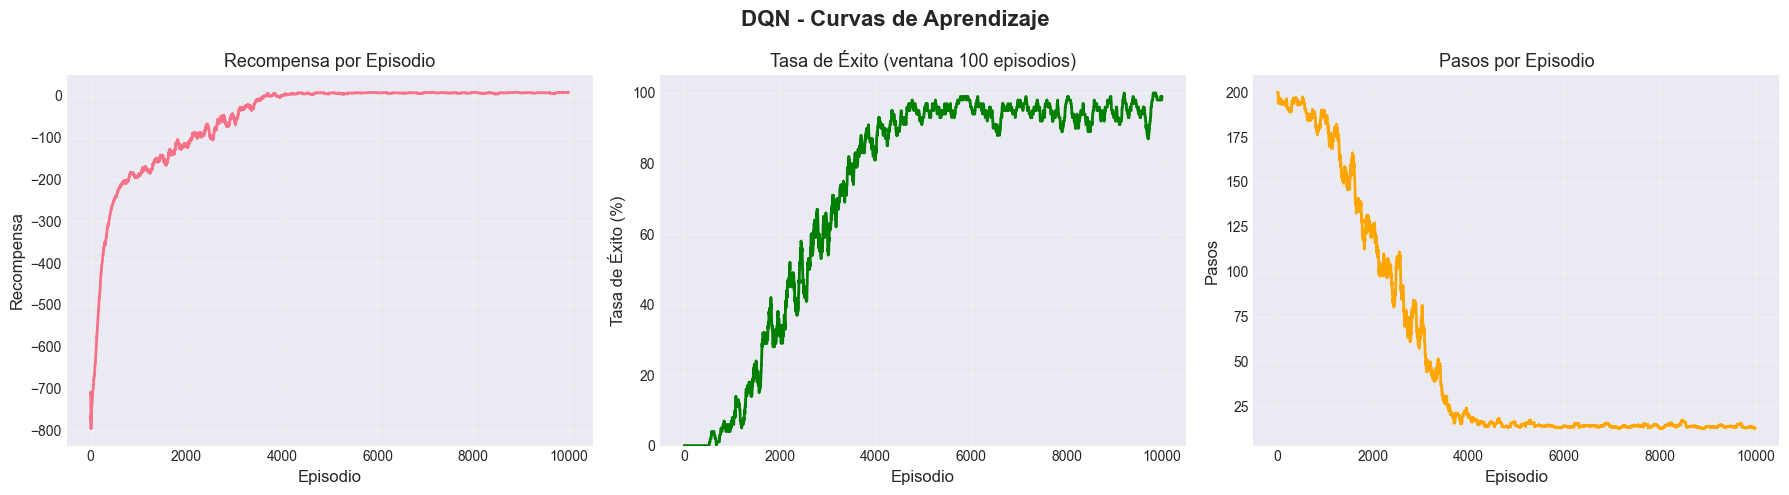

In [118]:
plot_training_curves(dqn_metrics, 'DQN - Curvas de Aprendizaje')

## Paso 6: Implementación de SARSA

In [119]:
class SARSAAgent:
  """Agente SARSA (on-policy) para entornos discretos."""

  def __init__(self, n_states, n_actions, learning_rate=0.1, discount_factor=0.99,
               epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
    self.n_states = n_states
    self.n_actions = n_actions
    self.lr = learning_rate
    self.gamma = discount_factor
    self.epsilon = epsilon_start
    self.epsilon_end = epsilon_end
    self.epsilon_decay = epsilon_decay

    # Tabla Q inicializada en ceros
    self.q_table = np.zeros((n_states, n_actions))

  def select_action(self, state, training=True):
    """Selecciona acción usando política epsilon-greedy."""
    if training and random.random() < self.epsilon:
      return random.randint(0, self.n_actions - 1)
    else:
      return np.argmax(self.q_table[state])

  def update(self, state, action, reward, next_state, next_action, done):
    """Actualiza la tabla Q usando la ecuación de SARSA (on-policy)."""
    current_q = self.q_table[state, action]

    # On-policy: usa el valor Q de la acción TOMADA en el siguiente estado
    next_q = self.q_table[next_state, next_action] if not done else 0

    # Q(s,a) ← Q(s,a) + α[r + γ Q(s',a') - Q(s,a)]
    new_q = current_q + self.lr * (reward + self.gamma * next_q - current_q)
    self.q_table[state, action] = new_q

  def decay_epsilon(self):
    """Reduce epsilon para explorar menos con el tiempo."""
    self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [120]:
def train_sarsa(env, num_episodes=15000):
  """Entrena un agente SARSA y registra métricas."""

  agent = SARSAAgent(
    n_states=env.observation_space.n,
    n_actions=env.action_space.n,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995
  )

  # Métricas de entrenamiento
  episode_rewards = []
  episode_steps = []
  success_rate = []
  recent_successes = deque(maxlen=100)

  print_info("Entrenando SARSA...")
  start_time = time.time()

  for episode in range(num_episodes):
    state, info = env.reset()
    action = agent.select_action(state, training=True)  # Selecciona primera acción

    total_reward = 0
    steps = 0
    done = False

    while not done:
      next_state, reward, terminated, truncated, info = env.step(action)
      done = terminated or truncated

      # Selecciona siguiente acción (importante: antes de actualizar)
      next_action = agent.select_action(next_state, training=True)

      # Actualiza Q-table con SARSA (usa next_action, no max)
      agent.update(state, action, reward, next_state, next_action, done)

      total_reward += reward
      steps += 1

      state = next_state
      action = next_action

    # Registrar métricas
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    recent_successes.append(1 if total_reward > 0 else 0)
    success_rate.append(np.mean(recent_successes))

    agent.decay_epsilon()

    # Progreso cada 1000 episodios
    if (episode + 1) % 1000 == 0:
      avg_reward = np.mean(episode_rewards[-100:])
      avg_steps = np.mean(episode_steps[-100:])
      current_success = success_rate[-1] * 100
      print_info(f"Episodio {episode + 1}/{num_episodes} | "
            f"Recompensa: {avg_reward:.2f} | "
            f"Pasos: {avg_steps:.1f} | "
            f"Éxito: {current_success:.1f}% | "
            f"ε: {agent.epsilon:.3f}")

  training_time = time.time() - start_time
  print_success(f"Entrenamiento completado en {training_time:.2f} segundos")

  return agent, {
    'rewards': episode_rewards,
    'steps': episode_steps,
    'success_rate': success_rate,
    'training_time': training_time
  }

sarsa_agent, sarsa_metrics = train_sarsa(env, num_episodes=10000)

ℹ Entrenando SARSA...
ℹ Episodio 1000/10000 | Recompensa: -275.65 | Pasos: 104.2 | Éxito: 1.0% | ε: 0.606
ℹ Episodio 2000/10000 | Recompensa: -53.31 | Pasos: 36.0 | Éxito: 11.0% | ε: 0.368
ℹ Episodio 3000/10000 | Recompensa: -13.67 | Pasos: 21.1 | Éxito: 29.0% | ε: 0.223
ℹ Episodio 4000/10000 | Recompensa: 0.51 | Pasos: 15.4 | Éxito: 56.0% | ε: 0.135
ℹ Episodio 5000/10000 | Recompensa: 2.94 | Pasos: 14.7 | Éxito: 65.0% | ε: 0.082
ℹ Episodio 6000/10000 | Recompensa: 4.70 | Pasos: 14.4 | Éxito: 81.0% | ε: 0.050
ℹ Episodio 7000/10000 | Recompensa: 6.16 | Pasos: 13.8 | Éxito: 87.0% | ε: 0.030
ℹ Episodio 8000/10000 | Recompensa: 7.53 | Pasos: 13.2 | Éxito: 97.0% | ε: 0.018
ℹ Episodio 9000/10000 | Recompensa: 7.36 | Pasos: 13.1 | Éxito: 94.0% | ε: 0.011
ℹ Episodio 10000/10000 | Recompensa: 6.24 | Pasos: 13.7 | Éxito: 90.0% | ε: 0.010
✓ Entrenamiento completado en 5.65 segundos


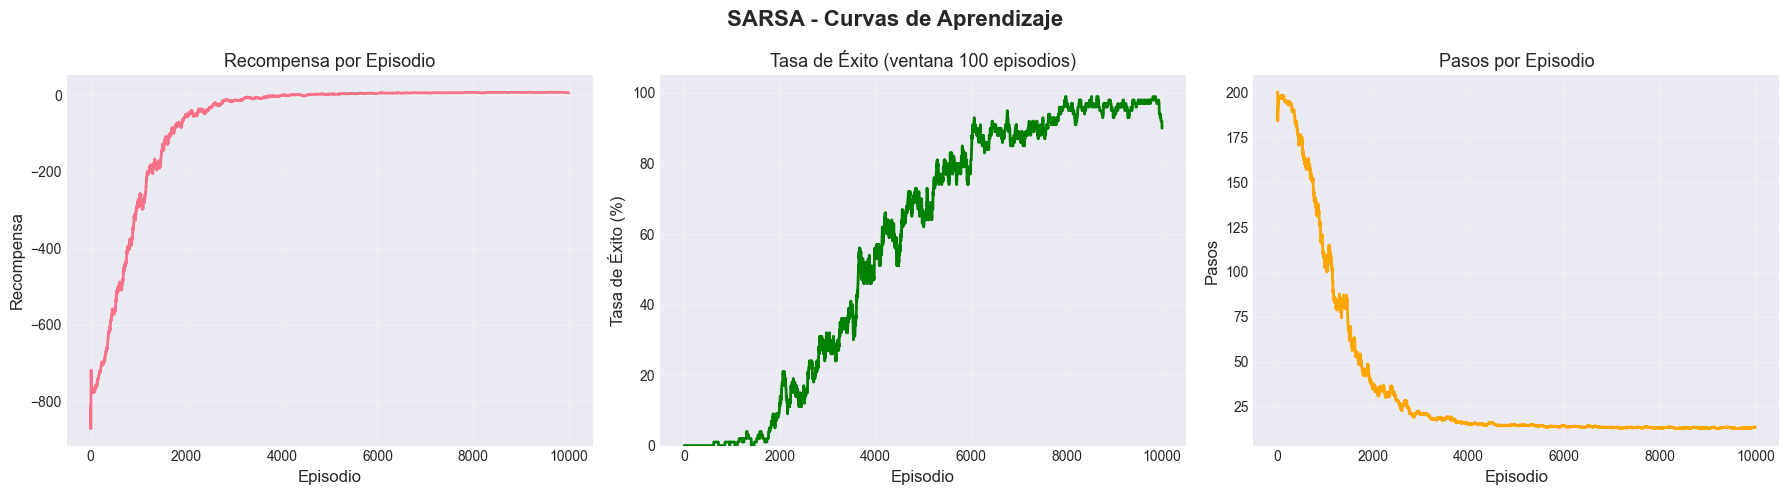

In [121]:
plot_training_curves(sarsa_metrics, 'SARSA - Curvas de Aprendizaje')

## Paso 7: Evaluación de las políticas finales

In [122]:
def evaluate_agent(agent, env, num_episodes=100, render_sample=True):
  """Evalúa un agente entrenado sin exploración."""

  episode_rewards = []
  episode_steps = []
  successes = 0

  for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    steps = 0
    done = False

    # Renderizar solo el primer episodio si se solicita
    if render_sample and episode == 0:
      print("\nEjemplo de episodio de evaluación:")
      print(env.render())

    while not done:
      action = agent.select_action(state, training=False)
      next_state, reward, terminated, truncated, info = env.step(action)
      done = terminated or truncated

      total_reward += reward
      steps += 1
      state = next_state

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    if total_reward > 0:
      successes += 1

    if render_sample and episode == 0:
      print(f"Resultado: Recompensa = {total_reward}, Pasos = {steps}")

  # Calcular métricas
  avg_reward = np.mean(episode_rewards)
  success_rate = successes / num_episodes
  successful_episodes = [steps for i, steps in enumerate(episode_steps) if episode_rewards[i] > 0]
  avg_steps_success = np.mean(successful_episodes) if successful_episodes else 0

  return {
    'avg_reward': avg_reward,
    'success_rate': success_rate,
    'avg_steps_success': avg_steps_success,
    'all_rewards': episode_rewards,
    'all_steps': episode_steps
  }

In [123]:
# Evaluar los tres agentes
print("EVALUANDO Q-LEARNING")
qlearning_eval = evaluate_agent(qlearning_agent, env, num_episodes=100)

print("EVALUANDO DQN")
dqn_eval = evaluate_agent(dqn_agent, env, num_episodes=100)

print("EVALUANDO SARSA")
sarsa_eval = evaluate_agent(sarsa_agent, env, num_episodes=100)

EVALUANDO Q-LEARNING

Ejemplo de episodio de evaluación:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Resultado: Recompensa = 3, Pasos = 18
EVALUANDO DQN

Ejemplo de episodio de evaluación:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Resultado: Recompensa = 7, Pasos = 14
EVALUANDO SARSA

Ejemplo de episodio de evaluación:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Resultado: Recompensa = 8, Pasos = 13


## Paso 8: Cálculo del tiempo de convergencia

In [124]:
def find_convergence_episode(success_rate_history, threshold=0.90, window=500):
  """
  Encuentra el episodio donde el algoritmo convergió.
  Convergencia: tasa de éxito >= threshold de forma consistente.
  """
  for i in range(len(success_rate_history) - window):
    # Verifica si en una ventana de episodios la tasa se mantiene alta
    window_avg = np.mean(success_rate_history[i:i + window])
    if window_avg >= threshold:
      return i
  return len(success_rate_history)  # No convergió


# Calcular convergencia para cada algoritmo
qlearning_convergence = find_convergence_episode(qlearning_metrics['success_rate'], threshold=0.90)
dqn_convergence = find_convergence_episode(dqn_metrics['success_rate'], threshold=0.90)
sarsa_convergence = find_convergence_episode(sarsa_metrics['success_rate'], threshold=0.90)

print("Tiempo de Convergencia (episodio donde se alcanza 90% de éxito sostenido):")
print(f"  Q-Learning: {qlearning_convergence} episodios")
print(f"  DQN: {dqn_convergence} episodios")
print(f"  SARSA: {sarsa_convergence} episodios")

Tiempo de Convergencia (episodio donde se alcanza 90% de éxito sostenido):
  Q-Learning: 6382 episodios
  DQN: 4017 episodios
  SARSA: 7146 episodios


## Paso 9: Tabla comparativa de algoritmos

In [125]:
# Crear tabla comparativa
from IPython.display import display
comparison_data = {
  'Algoritmo': ['Q-Learning', 'DQN', 'SARSA'],
  'Recompensa Final (Return Final)': [
    f"{qlearning_eval['avg_reward']:.2f}",
    f"{dqn_eval['avg_reward']:.2f}",
    f"{sarsa_eval['avg_reward']:.2f}"
  ],
  'Tasa de Éxito Final (Success Rate)': [
    f"{qlearning_eval['success_rate']*100:.1f}%",
    f"{dqn_eval['success_rate']*100:.1f}%",
    f"{sarsa_eval['success_rate']*100:.1f}%"
  ],
  'Tiempo de Convergencia (episodios)': [
    qlearning_convergence if qlearning_convergence < len(qlearning_metrics['success_rate']) else "No convergió",
    dqn_convergence if dqn_convergence < len(dqn_metrics['success_rate']) else "No convergió",
    sarsa_convergence if sarsa_convergence < len(sarsa_metrics['success_rate']) else "No convergió"
  ],
  'Pasos de Éxito Final (promedio)': [
    f"{qlearning_eval['avg_steps_success']:.1f}",
    f"{dqn_eval['avg_steps_success']:.1f}",
    f"{sarsa_eval['avg_steps_success']:.1f}"
  ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Algoritmo,Recompensa Final (Return Final),Tasa de Éxito Final (Success Rate),Tiempo de Convergencia (episodios),Pasos de Éxito Final (promedio)
0,Q-Learning,7.78,100.0%,6382,13.2
1,DQN,5.93,99.0%,4017,13.0
2,SARSA,7.79,100.0%,7146,13.2


## Paso 10: Gráficas comparativas de los tres algoritmos

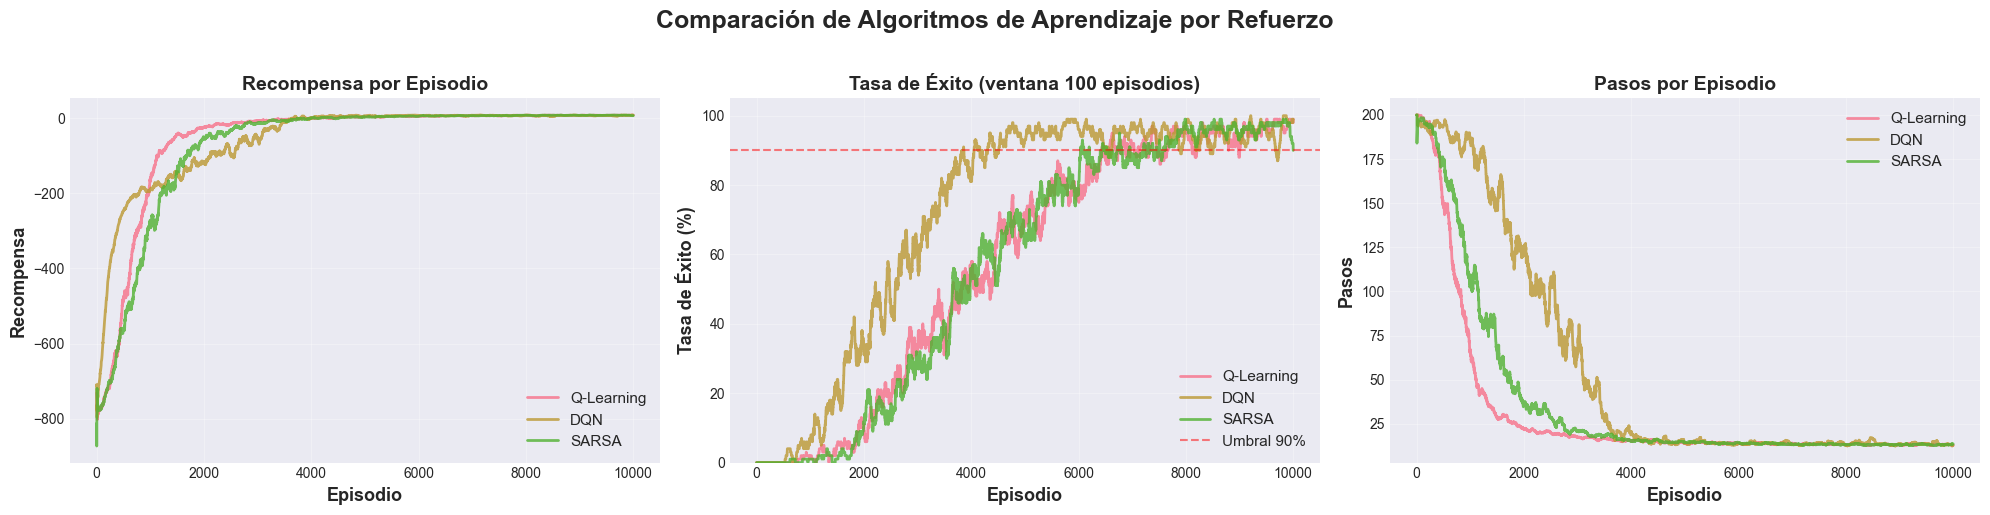

In [126]:
# Función auxiliar de suavizado
def smooth_curve(data, window=100):
  return pd.Series(data).rolling(window=window, min_periods=1).mean()


# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Comparación de Algoritmos de Aprendizaje por Refuerzo',
             fontsize=18, fontweight='bold', y=1.02)

# GRÁFICA 1: Recompensas durante entrenamiento
axes[0].plot(smooth_curve(qlearning_metrics['rewards']),
             label='Q-Learning', linewidth=2, alpha=0.8)
axes[0].plot(smooth_curve(dqn_metrics['rewards']),
             label='DQN', linewidth=2, alpha=0.8)
axes[0].plot(smooth_curve(sarsa_metrics['rewards']),
             label='SARSA', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Episodio', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Recompensa', fontsize=13, fontweight='bold')
axes[0].set_title('Recompensa por Episodio', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3)

# GRÁFICA 2: Tasa de éxito durante entrenamiento
axes[1].plot(np.array(qlearning_metrics['success_rate']) * 100,
             label='Q-Learning', linewidth=2, alpha=0.8)
axes[1].plot(np.array(dqn_metrics['success_rate']) * 100,
             label='DQN', linewidth=2, alpha=0.8)
axes[1].plot(np.array(sarsa_metrics['success_rate']) * 100,
             label='SARSA', linewidth=2, alpha=0.8)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Umbral 90%')
axes[1].set_xlabel('Episodio', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tasa de Éxito (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Tasa de Éxito (ventana 100 episodios)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

# GRÁFICA 3: Pasos promedio por episodio
axes[2].plot(smooth_curve(qlearning_metrics['steps']),
             label='Q-Learning', linewidth=2, alpha=0.8)
axes[2].plot(smooth_curve(dqn_metrics['steps']),
             label='DQN', linewidth=2, alpha=0.8)
axes[2].plot(smooth_curve(sarsa_metrics['steps']),
             label='SARSA', linewidth=2, alpha=0.8)
axes[2].set_xlabel('Episodio', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Pasos', fontsize=13, fontweight='bold')
axes[2].set_title('Pasos por Episodio', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11, loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusión

### En conclusión, el aprendizaje por refuerzo permite crear agentes que toman decisiones inteligentes por sí mismos. Q Learning y SARSA, por ser tabulares, convergieron más rápido y con menor variabilidad, mientras que DQN tardó más, pero alcanzó un rendimiento casi igual, demostrando su capacidad para aproximar funciones en escenarios más complejos. Todas las políticas finales alcanzaron una alta tasa de éxito y rutas eficientes. Basicamente, para problemas discretos y pequeños es preferible Q Learning/SARSA por simplicidad y rapidez, por otro lado, DQN es valioso cuando el espacio crece o las representaciones requieren aproximación mediante redes.

# Referencias

### Contributors, P. (2023, 1 enero). Reinforcement Learning (DQN) tutorial. https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
### Introducing Q-Learning - Hugging Face Deep RL course. (s. f.). https://huggingface.co/learn/deep-rl-course/unit2/q-learning
### GeeksforGeeks. (2025, octubre 31). QLearning in Reinforcement Learning. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/q-learning-in-python/
### GeeksforGeeks. (2025, noviembre 11). SARSA (StateActionRewardStateAction) in Reinforcement Learning. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/sarsa-reinforcement-learning/
### Kaggle (2025, marzo, 05). SARSA Reinforcement Learning Algorithm: A Guide https://www.kaggle.com/code/evilspirit05/sarsa-reinforcement-learning-algorithm-a-guide/notebook